In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
weight = 0.3
bias = 0.9
X = torch.arange(0, 10, 0.08).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0800],
         [0.1600],
         [0.2400],
         [0.3200],
         [0.4000],
         [0.4800],
         [0.5600],
         [0.6400],
         [0.7200]]),
 tensor([[0.9000],
         [0.9240],
         [0.9480],
         [0.9720],
         [0.9960],
         [1.0200],
         [1.0440],
         [1.0680],
         [1.0920],
         [1.1160]]))

In [4]:
end_index = int(0.8*len(X))
X_train = X[:end_index]
X_test = X[end_index:]
y_train = y[:end_index]
y_test = y[end_index:]

In [23]:
def plot_data(train_data = X_train,
              test_data = X_test,
              train_labels = y_train,
              test_labels = y_test,
              pred_data= None):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c='b', s=2, label="Training data")
    plt.scatter(test_data, test_labels, c='r', s = 2, label="Testing data")
    if pred_data is not None:
        plt.scatter(test_data, pred_data, c='g', s = 3, label="Predicted data")
    plt.legend(prop={"size": 14})

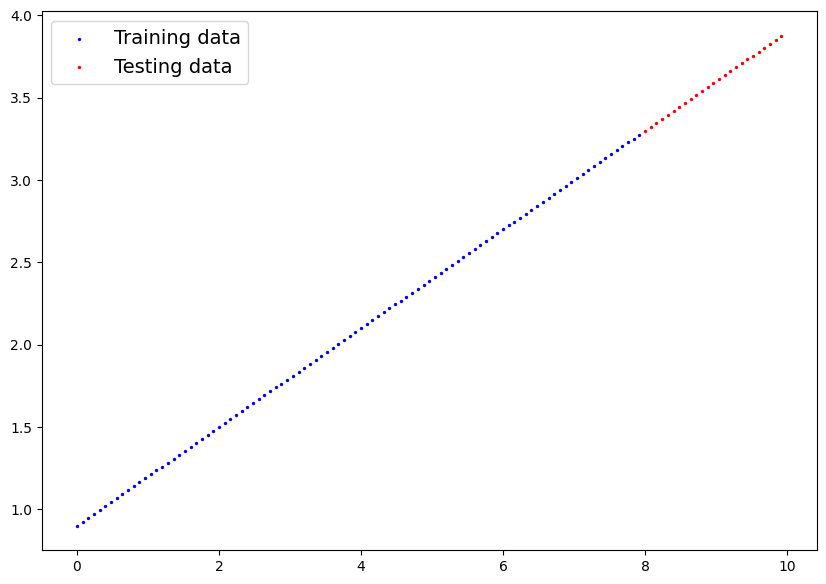

In [24]:
plot_data()

In [25]:
from torch import nn
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, X:torch.Tensor) ->torch.Tensor:
        return (self.weights * X + self.bias)

In [26]:
model = LinearModel()
model.state_dict()

OrderedDict([('weights', tensor([0.3639])), ('bias', tensor([0.5868]))])

In [27]:
loss_func = nn.L1Loss()
opt = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [30]:
epochs = 500
for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_func(y_pred, y_train)
    opt.zero_grad()
    loss.backward()
    opt.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_func(test_pred, y_test)
    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 20 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 40 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 60 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707


Epoch: 80 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 100 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 120 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 140 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 160 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 180 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 200 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 220 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 240 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 260 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 280 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 300 | Train loss: 0.025912649929523468 | Test loss: 0.3188003599643707
Epoch: 320 | Train loss: 0.025912649929523468 | Test loss: 0.3188

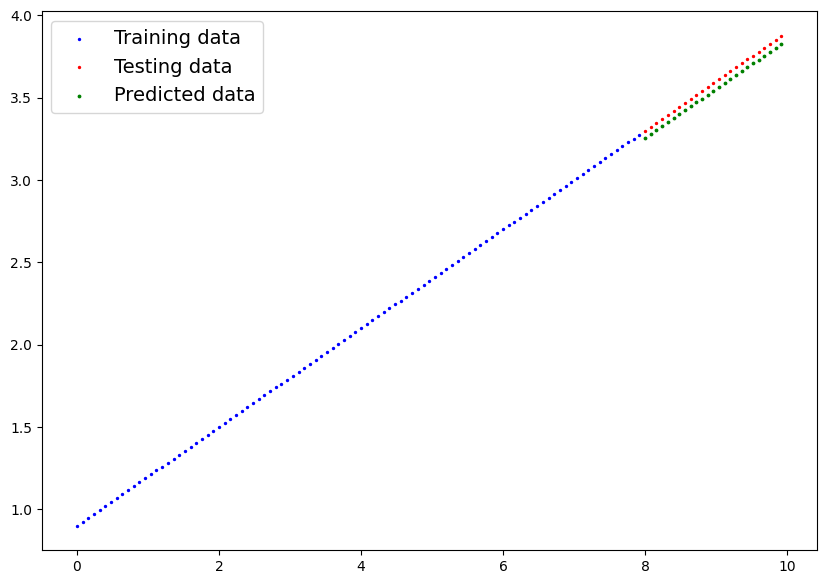

In [31]:
model.eval()
with torch.inference_mode():
    test_pred = model(X_test)
plot_data(pred_data=test_pred)